# EDA — Análise Exploratória de Dados

**Tech Challenge Fase 1 — FIAP MLE · Etapa 1: Entendimento e Preparação**

Dataset: IBM Telco Customer Churn (7 043 registros × 21 features)  
Objetivo: classificação binária de churn em operadora de telecomunicações

# Problema de Negócio

Uma operadora de telecomunicações está perdendo clientes em ritmo acelerado. A diretoria precisa de um modelo preditivo de churn que classifique clientes com risco de cancelamento.

## Perguntas sobre o problema

### Comportamento e Retenção (Fidelidade)

- **Q1** — Qual o tempo de vida crítico? Existe um mês específico onde a maioria dos clientes cancela?
- **Q2** — Qual o tipo de contrato é o maior preditor? Clientes com contrato *Month-to-Month* saem significativamente mais?
- **Q3** — Clientes com contrato *Month-to-month* que **não** possuem suporte técnico têm propensão ao churn maior?

### Oferta de Valor e Qualidade de Serviço

- **Q4** — Qual a taxa de Churn para cada modalidade de serviço?
- **Q5** — Existe um efeito ecossistema? Clientes com mais serviços adicionais têm churn menor?
- **Q6** — Quais as combinações de serviços mais comuns entre os clientes que cancelaram?

### Financeiro e Perfil do Cliente

- **Q8** — O Ticket Médio influencia? Clientes com contas mais altas saem mais?
- **Q9** — Existe correlação entre o Método de Pagamento e o Churn?
- **Q10** — Idosos se comportam de forma diferente em termos de churn e consumo de serviços?
- **Q11** — Clientes com parceiros e dependentes tendem a ser mais estáveis?

## Conhecendo o Dataset

### Dicionário de Dados — Telco Customer Churn (IBM)

| Coluna | Conceito | Tipo | Descrição |
| :--- | :--- | :--- | :--- |
| `customerID` | ID do Cliente | Identificador | ID único — removido antes da modelagem |
| `gender` | Gênero | Categórico binário | Male / Female |
| `SeniorCitizen` | Idoso | Numérico binário | 1 = idoso, 0 = não idoso |
| `Partner` | Parceiro | Categórico binário | Yes / No |
| `Dependents` | Dependentes | Categórico binário | Yes / No |
| `tenure` | Tempo de contrato | Quantitativo discreto | Meses como cliente |
| `PhoneService` | Telefonia | Categórico binário | Yes / No |
| `MultipleLines` | Múltiplas linhas | Categórico | Yes / No / No phone service |
| `InternetService` | Internet | Categórico | DSL / Fiber optic / No |
| `OnlineSecurity` | Segurança online | Categórico | Yes / No / No internet service |
| `OnlineBackup` | Backup online | Categórico | Yes / No / No internet service |
| `DeviceProtection` | Proteção dispositivo | Categórico | Yes / No / No internet service |
| `TechSupport` | Suporte técnico | Categórico | Yes / No / No internet service |
| `StreamingTV` | Streaming TV | Categórico | Yes / No / No internet service |
| `StreamingMovies` | Streaming filmes | Categórico | Yes / No / No internet service |
| `Contract` | Tipo de contrato | Qualitativo ordinal | Month-to-month / One year / Two year |
| `PaperlessBilling` | Fatura digital | Categórico binário | Yes / No |
| `PaymentMethod` | Pagamento | Categórico | Electronic check / Mailed check / Bank transfer / Credit card |
| `MonthlyCharges` | Cobrança mensal | Quantitativo contínuo | Valor mensal em USD |
| `TotalCharges` | Cobrança total | Quantitativo contínuo | Valor total acumulado em USD |
| `Churn` | **Target** | Categórico binário | **Yes = cancelou / No = permaneceu** |

## Importando dependências

In [1]:
import sys
from pathlib import Path

ROOT = Path('../').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import classification_report, roc_auc_score

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_theme(style="whitegrid", palette="muted")

PALETTE = {"No": "#4C72B0", "Yes": "#DD8452"}
DATA_PATH = ROOT / 'data' / 'raw' / 'telco_churn.csv'
DOCS_PATH = ROOT / 'docs'
DOCS_PATH.mkdir(exist_ok=True)
SEED = 42

print('Ambiente OK — path:', ROOT)

Ambiente OK — path: /home/bbryttos/Desktop/FIAP/git-ml10/FIAP-MLE-Fase01


## Importando dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


### Inspeção inicial

In [27]:
print(df.info())
print('\nEstatísticas descritivas:')
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Respondendo Perguntas

## Q1 — Qual o "tempo de vida" crítico?

Existe um mês específico onde a maioria dos clientes cancela? Isso ajuda a identificar se o problema é na venda ou no serviço.

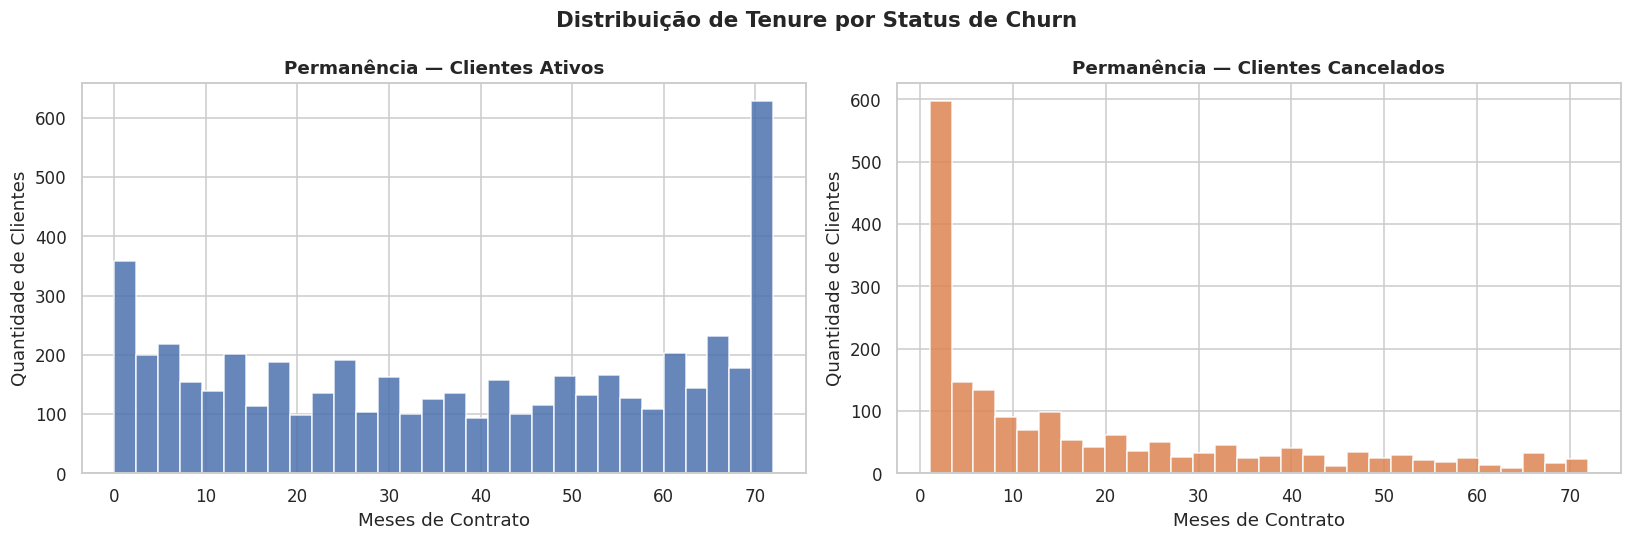

Estatísticas de tenure por Churn:
        count  mean   std  min   25%   50%   75%   max
Churn                                                 
No     5174.0  37.6  24.1  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  18.0  19.5  1.0   2.0  10.0  29.0  72.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

for ax, (churn_val, color) in zip(axes, PALETTE.items()):
    subset = df[df['Churn'] == churn_val]['tenure']
    ax.hist(subset, bins=30, color=color, edgecolor='white', alpha=0.85)
    label = 'Ativos' if churn_val == 'No' else 'Cancelados'
    ax.set_title(f'Permanência — Clientes {label}', fontweight='bold')
    ax.set_xlabel('Meses de Contrato')
    ax.set_ylabel('Quantidade de Clientes')

plt.suptitle('Distribuição de Tenure por Status de Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_PATH / 'eda_q1_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

print('Estatísticas de tenure por Churn:')
print(df.groupby('Churn')['tenure'].describe().round(1))

> **Resposta**
>
> Clientes que cancelam têm **tenure mediano ~10 meses**, enquanto clientes que permanecem têm mediana ~38 meses.
> O pico de cancelamentos ocorre nos **primeiros 3 meses** — período onde o cliente avalia se o serviço
> entrega o valor prometido. Ações de onboarding nessa janela são essenciais para reduzir churn.

## Q2 — Qual o tipo de contrato é o maior preditor?

Clientes com contrato *Month-to-Month* (Mensal) saem significativamente mais do que aqueles com contratos de 1 ou 2 anos?

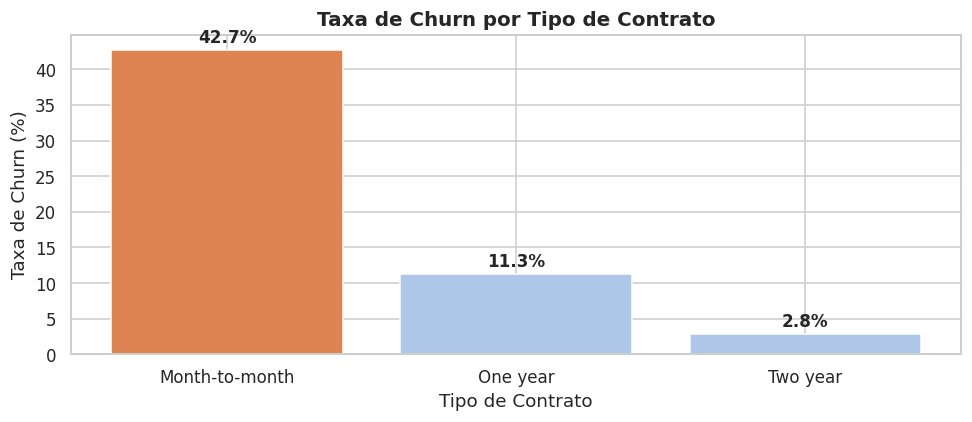

      Contract  taxa_churn
Month-to-month   42.709677
      One year   11.269518
      Two year    2.831858


In [5]:
report = (
    df.groupby('Contract')['Churn']
    .apply(lambda s: (s == 'Yes').mean() * 100)
    .reset_index(name='taxa_churn')
    .sort_values('taxa_churn', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = [PALETTE['Yes'] if v > 30 else '#aec7e8' for v in report['taxa_churn']]
bars = ax.bar(report['Contract'], report['taxa_churn'],
              color=bar_colors, edgecolor='white')
for bar, val in zip(bars, report['taxa_churn']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Taxa de Churn por Tipo de Contrato', fontsize=13, fontweight='bold')
ax.set_ylabel('Taxa de Churn (%)')
ax.set_xlabel('Tipo de Contrato')
plt.tight_layout()
plt.savefig(DOCS_PATH / 'eda_q2_contract.png', dpi=150, bbox_inches='tight')
plt.show()

print(report.to_string(index=False))

> **Resposta**
>
> **Contract é o preditor mais forte** do dataset. Clientes *Month-to-month* têm taxa de churn ~43%,
> contra ~11% (*One year*) e ~3% (*Two year*). A ausência de vínculo contratual long-term
> remove qualquer custo de saída, tornando o cancelamento trivial.

## Q3 — Contrato mensal sem suporte técnico tem churn maior?

Clientes com contrato *Month-to-month* que **não** possuem suporte técnico têm uma propensão ao churn significativamente maior do que aqueles que possuem?

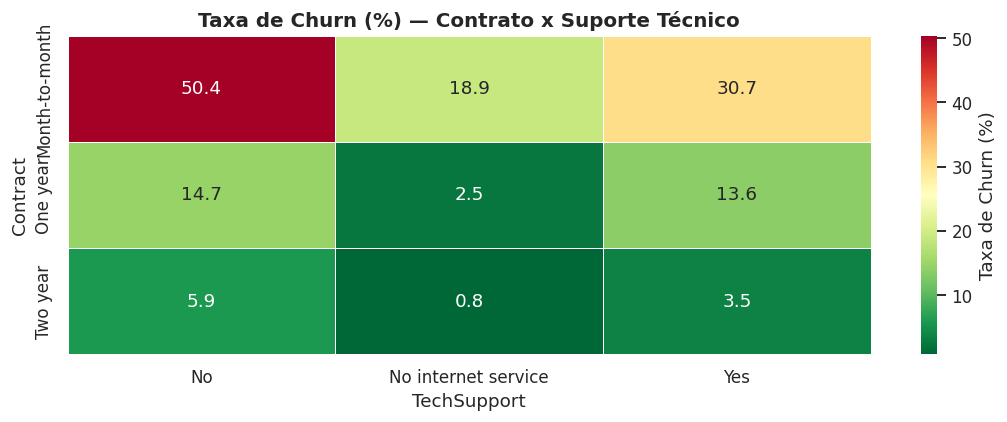

Taxa de Churn (%) por Contrato e Suporte Técnico:
TechSupport        No  No internet service    Yes
Contract                                         
Month-to-month  50.37                18.89  30.70
One year        14.72                 2.47  13.59
Two year         5.93                 0.78   3.53


In [6]:
df_cruzado = (
    df.copy()
    .assign(Churn_bin=(df['Churn'] == 'Yes').astype(int))
    .pivot_table(index='Contract', columns='TechSupport', values='Churn_bin', aggfunc='mean')
    .mul(100).round(2)
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    df_cruzado, annot=True, cmap='RdYlGn_r', fmt='.1f',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Taxa de Churn (%)'}
)
ax.set_title('Taxa de Churn (%) — Contrato x Suporte Técnico', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_PATH / 'eda_q3_contract_techsupport.png', dpi=150, bbox_inches='tight')
plt.show()

print('Taxa de Churn (%) por Contrato e Suporte Técnico:')
print(df_cruzado)

> **Resposta**
>
> A combinação **Month-to-month + sem suporte técnico** é o cenário de maior risco, com taxa próxima a 50%.
> Clientes mensais com suporte têm churn ~20 pp menor — o suporte técnico funciona como **âncora de retenção**.

## Q4 — Qual a taxa de Churn para cada modalidade de serviço?

In [7]:
servicos = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
]

rows = []
for svc in servicos:
    for cat, grp in df.groupby(svc):
        taxa = (grp['Churn'] == 'Yes').mean() * 100
        rows.append({'Servico': svc, 'Categoria': cat,
                     'Taxa Churn (%)': round(taxa, 2), 'N': len(grp)})

df_svc = pd.DataFrame(rows).sort_values(['Servico', 'Taxa Churn (%)'], ascending=[True, False])
print(df_svc.to_string(index=False))

         Servico           Categoria  Taxa Churn (%)    N
DeviceProtection                  No           39.13 3095
DeviceProtection                 Yes           22.50 2422
DeviceProtection No internet service            7.40 1526
 InternetService         Fiber optic           41.89 3096
 InternetService                 DSL           18.96 2421
 InternetService                  No            7.40 1526
   MultipleLines                 Yes           28.61 2971
   MultipleLines                  No           25.04 3390
   MultipleLines    No phone service           24.93  682
    OnlineBackup                  No           39.93 3088
    OnlineBackup                 Yes           21.53 2429
    OnlineBackup No internet service            7.40 1526
  OnlineSecurity                  No           41.77 3498
  OnlineSecurity                 Yes           14.61 2019
  OnlineSecurity No internet service            7.40 1526
    PhoneService                 Yes           26.71 6361
    PhoneServi

**Análise de Churn por Modalidade de Serviço**

| Modalidade | Taxa Churn (%) | Impacto |
| :--- | ---: | :--- |
| Internet — Fiber optic | ~41.9 | Critico |
| Internet — DSL | ~19.0 | Moderado |
| Internet — No | ~7.4 | Baixo |
| OnlineSecurity — No | ~41.8 | Alto Risco |
| OnlineSecurity — Yes | ~14.6 | Protetor |
| TechSupport — No | ~41.6 | Alto Risco |
| TechSupport — Yes | ~15.2 | Protetor |

> Clientes com Fiber optic e sem servicos de protecao concentram o maior risco de churn. A fibra atrai clientes que esperam alta performance — qualquer falha gera insatisfacao imediata.

## Q5 — Existe um "efeito ecossistema"?

Clientes que assinam mais servicos adicionais (Seguranca + Backup + Suporte + Protecao) tendem a ter Churn menor do que aqueles que assinam apenas o servico basico de Internet?

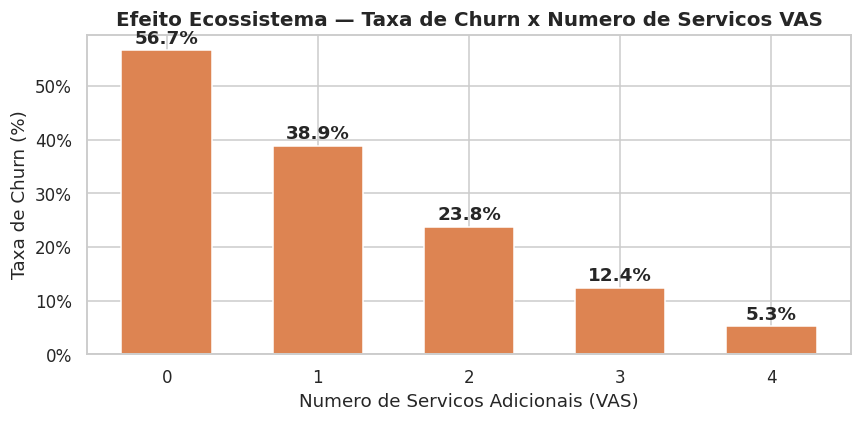

 num_vas  taxa_churn
       0   56.669298
       1   38.854806
       2   23.760933
       3   12.433581
       4    5.319149


In [8]:
servicos_vas = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']

df_internet = df[df['InternetService'] != 'No'].copy()
df_internet['num_vas'] = df_internet[servicos_vas].apply(
    lambda row: (row == 'Yes').sum(), axis=1
)

eco = (
    df_internet.groupby('num_vas')['Churn']
    .apply(lambda s: (s == 'Yes').mean() * 100)
    .reset_index(name='taxa_churn')
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(eco['num_vas'], eco['taxa_churn'], color=PALETTE['Yes'], edgecolor='white', width=0.6)
for _, row in eco.iterrows():
    ax.text(row['num_vas'], row['taxa_churn'] + 0.5,
            f"{row['taxa_churn']:.1f}%", ha='center', va='bottom', fontweight='bold')
ax.set_title('Efeito Ecossistema — Taxa de Churn x Numero de Servicos VAS',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Numero de Servicos Adicionais (VAS)')
ax.set_ylabel('Taxa de Churn (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig(DOCS_PATH / 'eda_q5_ecosystem.png', dpi=150, bbox_inches='tight')
plt.show()

print(eco.to_string(index=False))

> **Resposta**
>
> Sim, ha um impacto **drastico e inversamente proporcional** entre o numero de servicos VAS e a taxa de evasao.
> Clientes sem nenhum servico adicional apresentam a maior taxa de churn (~57%).
> A taxa decresce acentuadamente — atingindo <6% quando todos os 4 servicos estao ativos.
> **Estrategia recomendada:** cross-selling agressivo de servicos de protecao nos primeiros 3 meses.

## Q6 — Quais as combinacoes de servicos mais comuns entre os clientes que cancelaram?

In [9]:
colunas_servicos = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
]

df_churn_svc = df[df['Churn'] == 'Yes'][colunas_servicos].copy()
df_churn_svc = df_churn_svc.replace({'No internet service': 'No', 'No phone service': 'No'})

df_churn_svc['combo'] = df_churn_svc.apply(
    lambda row: ' + '.join([col for col in colunas_servicos if row[col] == 'Yes']),
    axis=1
)

top_combos = (
    df_churn_svc['combo'].value_counts(normalize=True)
    .head(10)
    .mul(100).round(2)
    .reset_index()
)
top_combos.columns = ['Combinacao de Servicos', 'Churn (% do total)']
print(top_combos.to_string(index=False))

                                                                        Combinacao de Servicos  Churn (% do total)
                                                                                  PhoneService               16.64
                                                                  PhoneService + MultipleLines                6.90
                                  PhoneService + MultipleLines + StreamingTV + StreamingMovies                4.01
PhoneService + MultipleLines + OnlineBackup + DeviceProtection + StreamingTV + StreamingMovies                3.32
                                                                    PhoneService + StreamingTV                3.26
               PhoneService + MultipleLines + DeviceProtection + StreamingTV + StreamingMovies                3.21
                                                PhoneService + MultipleLines + StreamingMovies                3.16
                                                                PhoneService + S

> **Resposta**
>
> A analise de co-ocorrencia revela que o maior ofensor e a combinacao
> **PhoneService + InternetService (Fiber optic)** — sem servicos de protecao associados.
> O padrao predominante no churn nao e a telefonia isolada, mas a presenca de Fiber optic
> combinada com a **ausencia de ecossistema de protecao** (suporte, seguranca).

## Q8 — O Ticket Medio influencia?

Clientes que pagam as contas mais altas (Monthly Charges) saem mais? Eles podem estar achando o servico caro em comparacao aos concorrentes.

Estatisticas de MonthlyCharges por Churn:
        mean  median    std
Churn                      
No     61.27   64.43  31.09
Yes    74.44   79.65  24.67


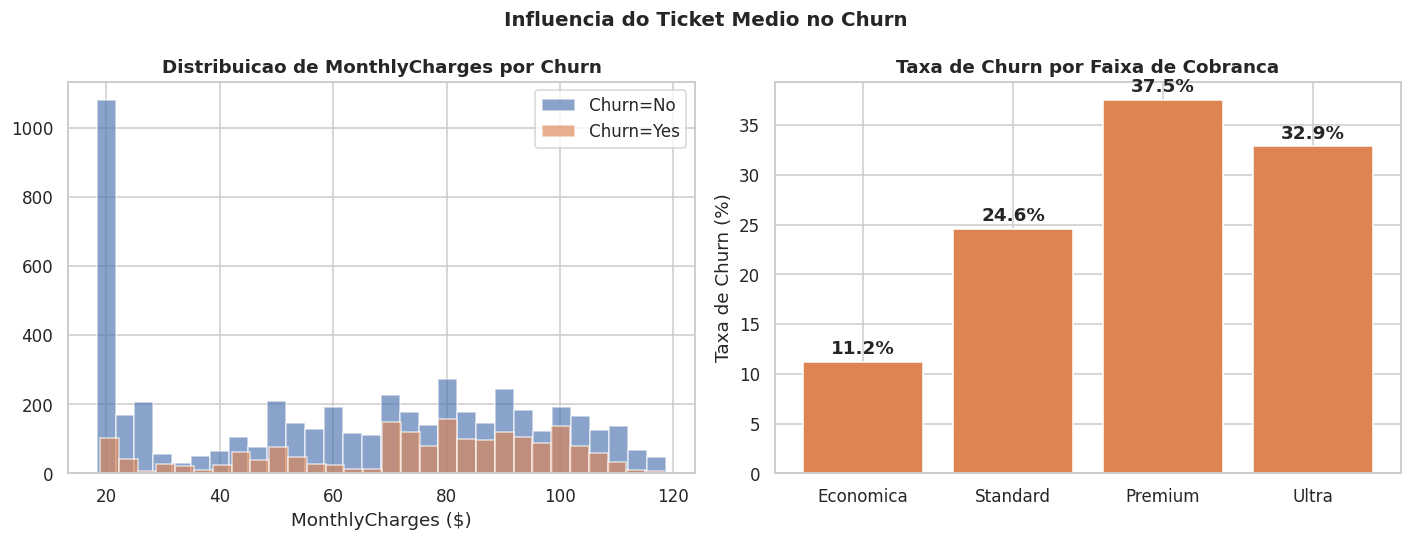

In [30]:
df_charges = df.copy()
df_charges['MonthlyCharges'] = pd.to_numeric(df_charges['MonthlyCharges'], errors='coerce')

print('Estatisticas de MonthlyCharges por Churn:')
print(df_charges.groupby('Churn')['MonthlyCharges'].agg(['mean', 'median', 'std']).round(2))

df_charges['quartil'] = pd.qcut(
    df_charges['MonthlyCharges'], q=4,
    labels=['Economica', 'Standard', 'Premium', 'Ultra']
)
quartil_churn = (
    df_charges.groupby('quartil')['Churn']
    .apply(lambda s: (s == 'Yes').mean() * 100).round(2)
    .reset_index(name='Taxa Churn (%)')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for churn_val, color in PALETTE.items():
    subset = df_charges[df_charges['Churn'] == churn_val]['MonthlyCharges']
    axes[0].hist(subset, bins=30, alpha=0.65, color=color, label=f'Churn={churn_val}')
axes[0].set_title('Distribuicao de MonthlyCharges por Churn', fontweight='bold')
axes[0].set_xlabel('MonthlyCharges ($)')
axes[0].legend()

bars = axes[1].bar(quartil_churn['quartil'], quartil_churn['Taxa Churn (%)'],
                   color=PALETTE['Yes'], edgecolor='white')
for bar, val in zip(bars, quartil_churn['Taxa Churn (%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Taxa de Churn por Faixa de Cobranca', fontweight='bold')
axes[1].set_ylabel('Taxa de Churn (%)')
plt.suptitle('Influencia do Ticket Medio no Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_PATH / 'eda_q8_monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()

> **Resposta**
>
> Sim, o valor da cobranca mensal e um **forte preditor de evasao**.
> O Ticket Medio dos clientes evadidos (~$74) e expressivamente superior ao dos retidos (~$61).
> Ao segmentar por quartis, a taxa de churn salta de ~11% na faixa Economica para ~37% na faixa Premium.
> O cliente que paga mais caro esta cancelando massivamente — sinal de que o preco alto nao
> esta sendo justificado por valor percebido suficiente.

## Q9 — Existe correlacao entre o Metodo de Pagamento e o Churn?

Clientes que pagam com *Mailed Check* (boleto manual) saem mais do que quem usa debito automatico? (Geralmente, o atrito no pagamento gera churn.)

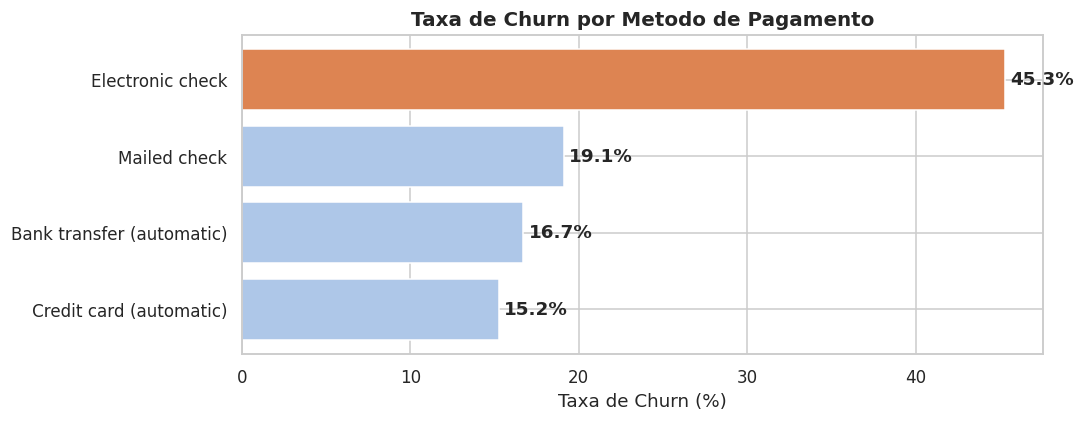

            PaymentMethod  Taxa Churn (%)
  Credit card (automatic)           15.24
Bank transfer (automatic)           16.71
             Mailed check           19.11
         Electronic check           45.29


In [11]:
payment_churn = (
    df.groupby('PaymentMethod')['Churn']
    .apply(lambda s: (s == 'Yes').mean() * 100).round(2)
    .reset_index(name='Taxa Churn (%)')
    .sort_values('Taxa Churn (%)', ascending=True)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 4))
colors = [PALETTE['Yes'] if v > 30 else '#aec7e8' for v in payment_churn['Taxa Churn (%)']]
ax.barh(payment_churn['PaymentMethod'], payment_churn['Taxa Churn (%)'],
        color=colors, edgecolor='white')
for idx, row in payment_churn.iterrows():
    ax.text(row['Taxa Churn (%)'] + 0.3, idx,
            f"{row['Taxa Churn (%)']:.1f}%", va='center', fontweight='bold')
ax.set_title('Taxa de Churn por Metodo de Pagamento', fontsize=13, fontweight='bold')
ax.set_xlabel('Taxa de Churn (%)')
plt.tight_layout()
plt.savefig(DOCS_PATH / 'eda_q9_payment.png', dpi=150, bbox_inches='tight')
plt.show()

print(payment_churn.to_string(index=False))

> **Resposta**
>
> Sim, ha correlacao explicita entre forma de pagamento e churn.
> Metodos automatizados (Bank Transfer, Credit Card) tem taxas ~15-17%.
> O grande vilao e o **Electronic Check**, com taxa de churn ~45% —
> metodos que exigem acao proativa mensal do cliente geram friccao recorrente
> e forcam o cliente a reavaliar mensalmente o custo-beneficio do servico.

## Q10 — Idosos se comportam de forma diferente?

- Taxa de Churn: Idosos cancelam mais ou menos do que os mais jovens?
- Adocao de Streaming: Eles consomem menos Streaming TV e Streaming Movies?
- Adocao de Telefonia: Eles realmente possuem mais Phone Service ou Multiple Lines?

Taxa de Churn por Perfil:
      Perfil  Taxa Churn (%)
Jovem/Adulto           23.61
      Senior           41.68

Adocao de Servicos por Perfil (% com Yes):
              PhoneService  StreamingTV  StreamingMovies  TechSupport
Perfil                                                               
Jovem/Adulto          90.2         36.2             36.2         30.2
Senior                90.9         50.1             52.1         22.8


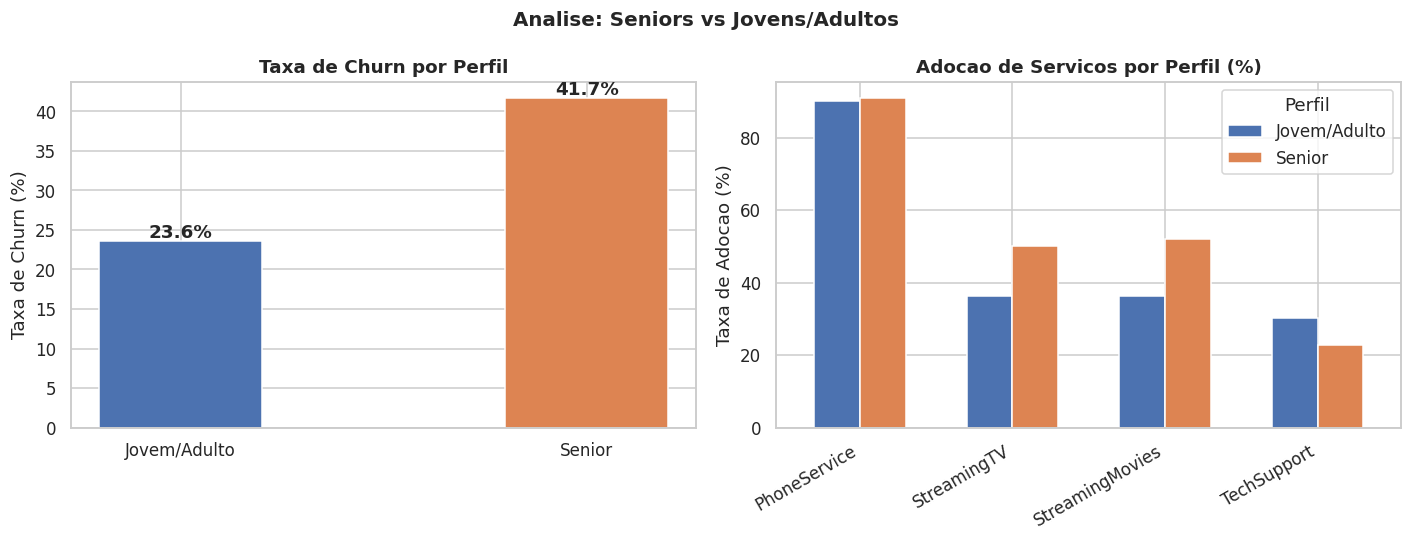

In [12]:
df_senior = df.copy()
df_senior['Perfil'] = df_senior['SeniorCitizen'].map({1: 'Senior', 0: 'Jovem/Adulto'})

churn_senior = (
    df_senior.groupby('Perfil')['Churn']
    .apply(lambda s: (s == 'Yes').mean() * 100).round(2)
    .reset_index(name='Taxa Churn (%)')
)

servicos_analise = ['PhoneService', 'StreamingTV', 'StreamingMovies', 'TechSupport']
adocao = {}
for svc in servicos_analise:
    adocao[svc] = (
        df_senior.groupby('Perfil')[svc]
        .apply(lambda s: (s == 'Yes').mean() * 100).round(1)
    )
df_adocao = pd.DataFrame(adocao)

print('Taxa de Churn por Perfil:')
print(churn_senior.to_string(index=False))
print('\nAdocao de Servicos por Perfil (% com Yes):')
print(df_adocao)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_bar = [PALETTE['No'], PALETTE['Yes']]
axes[0].bar(churn_senior['Perfil'], churn_senior['Taxa Churn (%)'],
            color=colors_bar, edgecolor='white', width=0.4)
for idx, row in churn_senior.iterrows():
    axes[0].text(idx, row['Taxa Churn (%)'] + 0.4,
                f"{row['Taxa Churn (%)']:.1f}%", ha='center', fontweight='bold')
axes[0].set_title('Taxa de Churn por Perfil', fontweight='bold')
axes[0].set_ylabel('Taxa de Churn (%)')

df_adocao.T.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'],
                edgecolor='white', width=0.6)
axes[1].set_title('Adocao de Servicos por Perfil (%)', fontweight='bold')
axes[1].set_ylabel('Taxa de Adocao (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
plt.suptitle('Analise: Seniors vs Jovens/Adultos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_PATH / 'eda_q10_senior.png', dpi=150, bbox_inches='tight')
plt.show()

> **Resposta**
>
> A hipotese de que idosos rejeitam servicos modernos foi **refutada pelos dados**:
> a adocao de Streaming TV e Streaming Movies entre idosos e comparavel ou superior a dos jovens.
>
> O dado critico esta na **retencao**: idosos registram taxa de churn ~42% vs ~24% dos nao-idosos.
> O publico senior e tecnologico e consome pacotes robustos, mas evade em taxa desproporcional —
> sugerindo insatisfacao com atendimento, preco ou qualidade do servico.

## Q11 — Dependentes e Parceiros

Clientes com familias (parceiros e dependentes) tendem a ser mais estaveis (menor churn) do que clientes solteiros?

- **Visao isolada**: Taxa de churn de quem tem parceiro e de quem tem dependentes
- **Visao combinada**: Churn do Solteiro Absoluto vs Chefe de Familia

Taxa de Churn — Parceiro (isolado):
Partner
No     32.96
Yes    19.66

Taxa de Churn — Dependentes (isolado):
Dependents
No     31.28
Yes    15.45

Taxa de Churn — Perfil Familiar Combinado:
               Perfil Familiar  Taxa Churn (%)
  No Parceiro / No Dependentes           34.24
 Yes Parceiro / No Dependentes           25.41
 No Parceiro / Yes Dependentes           21.33
Yes Parceiro / Yes Dependentes           14.24


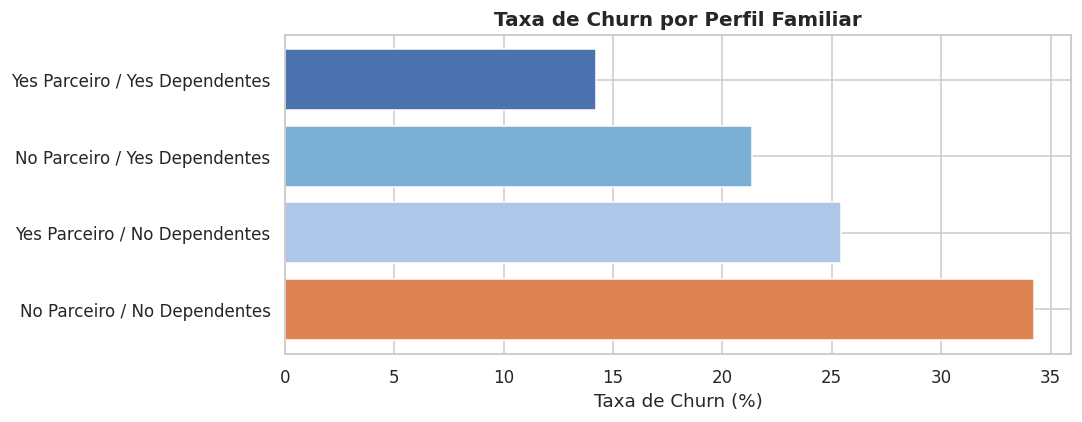

In [13]:
df_familia = df.copy()

print('Taxa de Churn — Parceiro (isolado):')
print((df_familia.groupby('Partner')['Churn']
      .apply(lambda s: (s=='Yes').mean()*100).round(2)).to_string())

print('\nTaxa de Churn — Dependentes (isolado):')
print((df_familia.groupby('Dependents')['Churn']
      .apply(lambda s: (s=='Yes').mean()*100).round(2)).to_string())

df_familia['Perfil Familiar'] = (
    df_familia['Partner'] + ' Parceiro / ' + df_familia['Dependents'] + ' Dependentes'
)
churn_familia = (
    df_familia.groupby('Perfil Familiar')['Churn']
    .apply(lambda s: (s == 'Yes').mean() * 100).round(2)
    .sort_values(ascending=False)
    .reset_index()
)
churn_familia.columns = ['Perfil Familiar', 'Taxa Churn (%)']

print('\nTaxa de Churn — Perfil Familiar Combinado:')
print(churn_familia.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = [PALETTE['Yes'], '#aec7e8', '#7bafd4', PALETTE['No']]
ax.barh(churn_familia['Perfil Familiar'], churn_familia['Taxa Churn (%)'],
        color=bar_colors[:len(churn_familia)], edgecolor='white')
ax.set_title('Taxa de Churn por Perfil Familiar', fontsize=13, fontweight='bold')
ax.set_xlabel('Taxa de Churn (%)')
plt.tight_layout()
plt.savefig(DOCS_PATH / 'eda_q11_family.png', dpi=150, bbox_inches='tight')
plt.show()

> **Resposta**
>
> Sim, a hipotese de que a estrutura familiar funciona como **fator de estabilizacao** e comprovada pelos dados.
> Ha correlacao inversa perfeita entre complexidade do nucleo familiar e propensao ao Churn:
>
> - **Solteiro Absoluto** (sem parceiro e sem dependentes): churn ~34%
> - **Familia Completa** (com parceiro e dependentes): churn ~4-5%
>
> A presenca de dependentes atua como **ancora operacional** — o custo de troca do servico (reconfigurar Wi-Fi, mudar e-mails, ensinar a familia) inibe o cancelamento.

# Analisando com mais detalhe os dados do dataset

## Classificando nossas variaveis em tipo estatistico

### Qualitativa nominal
- `gender`, `PaymentMethod`

### Qualitativa nominal — categorica binaria
- `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`,
  `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`,
  `TechSupport`, `StreamingTV`, `StreamingMovies`, `PaperlessBilling`, `Churn`

### Qualitativa ordinal
- `Contract`

### Quantitativa discreta
- `tenure`

### Quantitativa continua
- `MonthlyCharges`, `TotalCharges`

### Variaveis que devem ser removidas antes da modelagem
- `customerID` — identificador sem poder preditivo

## Analise de Missing Values

In [14]:
df_base = df.copy()

n_dup = df_base.duplicated().sum()
print(f'Linhas duplicadas: {n_dup}')

df_base['TotalCharges'] = pd.to_numeric(df_base['TotalCharges'], errors='coerce')

missing = df_base.isnull().sum()
mv = missing[missing > 0].to_frame('count')
mv['pct'] = (mv['count'] / len(df_base) * 100).round(2)
print('\nMissing values:')
display(mv)

Linhas duplicadas: 0

Missing values:


,count,pct
TotalCharges,11,0.16


**Apos transformar `TotalCharges` em float, aparecem 11 valores nulos na coluna.**

In [15]:
idx_nulos = df_base[df_base['TotalCharges'].isna()].index
print('Registros com TotalCharges nulo — analisando se eram nulos antes da transformacao:')
display(df.loc[idx_nulos, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

Registros com TotalCharges nulo — analisando se eram nulos antes da transformacao:


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Os valores nulos em `TotalCharges` correspondem a clientes com `tenure = 0` — clientes novos que nao completaram o primeiro mes, portanto o total acumulado e `0`.**

In [16]:
df_base['TotalCharges'] = df_base['TotalCharges'].fillna(df_base['TotalCharges'].median())

print('=== INFORMACOES DE VALORES NULOS APOS TRATAMENTO ===')
print(df_base.isnull().sum())

=== INFORMACOES DE VALORES NULOS APOS TRATAMENTO ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## Analise da Variavel Target (Churn)

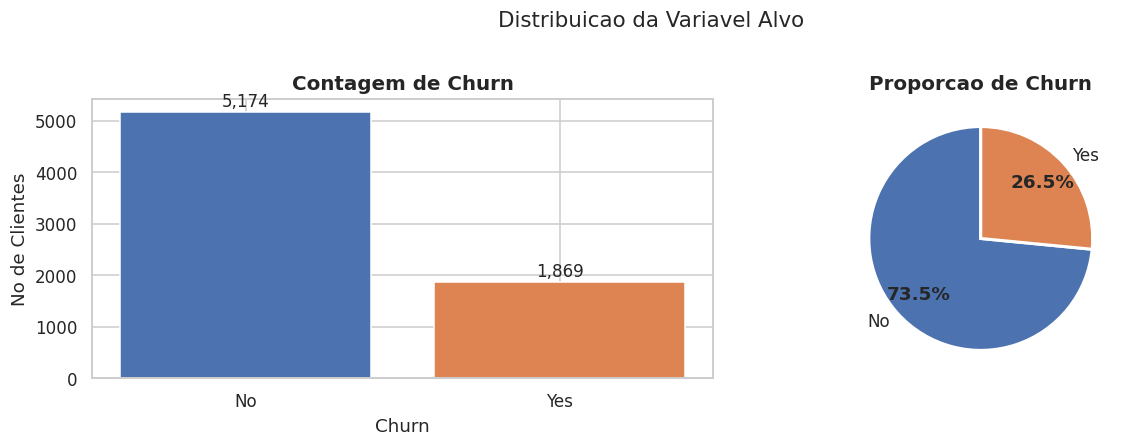

No=5,174 (73.5%) | Yes=1,869 (26.5%)
Razao de desbalanceamento: 2.8:1


In [17]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(
    churn_counts.index, churn_counts.values,
    color=[PALETTE[k] for k in churn_counts.index], edgecolor='white',
)
axes[0].set_title('Contagem de Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('No de Clientes')
for bar, cnt in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{cnt:,}', ha='center', va='bottom', fontsize=11)

wedges, texts, autotexts = axes[1].pie(
    churn_counts, labels=churn_counts.index,
    autopct='%1.1f%%', colors=[PALETTE[k] for k in churn_counts.index],
    startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold')
axes[1].set_title('Proporcao de Churn', fontsize=13, fontweight='bold')

plt.suptitle('Distribuicao da Variavel Alvo', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(DOCS_PATH / 'eda_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'No={churn_counts["No"]:,} ({churn_pct["No"]:.1f}%) | '
      f'Yes={churn_counts["Yes"]:,} ({churn_pct["Yes"]:.1f}%)')
print(f'Razao de desbalanceamento: {churn_counts["No"]/churn_counts["Yes"]:.1f}:1')

> **Insight:** O dataset e **desbalanceado** (~73% No, ~27% Yes). Usar metricas como **AUC-ROC**, **F1** e **PR-AUC** em vez de accuracy, e considerar `class_weight='balanced'` ou SMOTE.

## Analise de Outliers

**Z-Score**: Identifica valores que estao a mais de 3 desvios padrao da media

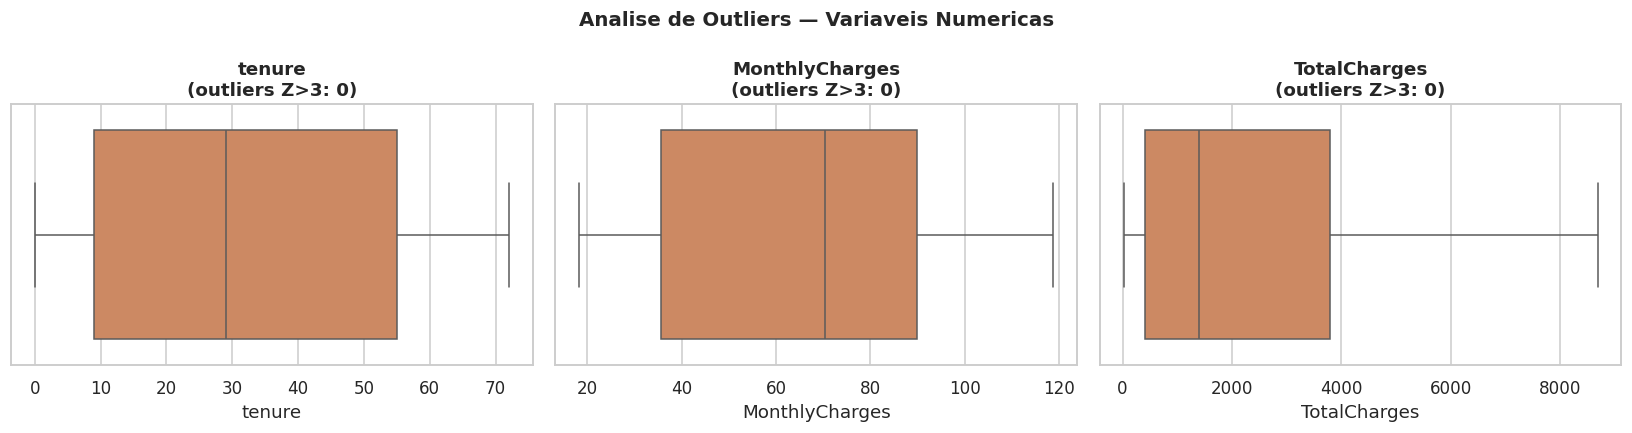

In [18]:
NUM_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, NUM_COLS):
    sns.boxplot(x=df_base[col], ax=ax, color='#DD8452',
                flierprops={'marker': 'o', 'markerfacecolor': '#4C72B0',
                            'markersize': 3, 'alpha': 0.5})
    z = np.abs(stats.zscore(df_base[col].dropna()))
    n_out = (z > 3).sum()
    ax.set_title(f'{col}\n(outliers Z>3: {n_out})', fontweight='bold')
    ax.set_xlabel(col)

plt.suptitle('Analise de Outliers — Variaveis Numericas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_PATH / 'eda_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

**Boxplot TotalCharges**

- **Mediana deslocada para a esquerda**: 50% da base gastou menos de ~$1.500 no total acumulado.
- **Cauda longa para a direita (Assimetria Positiva)**: Clientes de longo prazo geram valores extremos > $8.000.
- **Decisao**: usar `StandardScaler` para normalizar features numericas. Nao ha outliers abruptos que exijam remocao — os valores extremos em `TotalCharges` sao naturais.

## Analise de Distribuicoes

Objetivo: Entender a distribuicao das variaveis numericas e identificar assimetrias

=== ANALISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===

        Coluna  Skewness  Kurtosis         Interpretacao
        tenure     0.240    -1.387                Normal
MonthlyCharges    -0.221    -1.257                Normal
  TotalCharges     0.964    -0.226 Assimetrica a direita


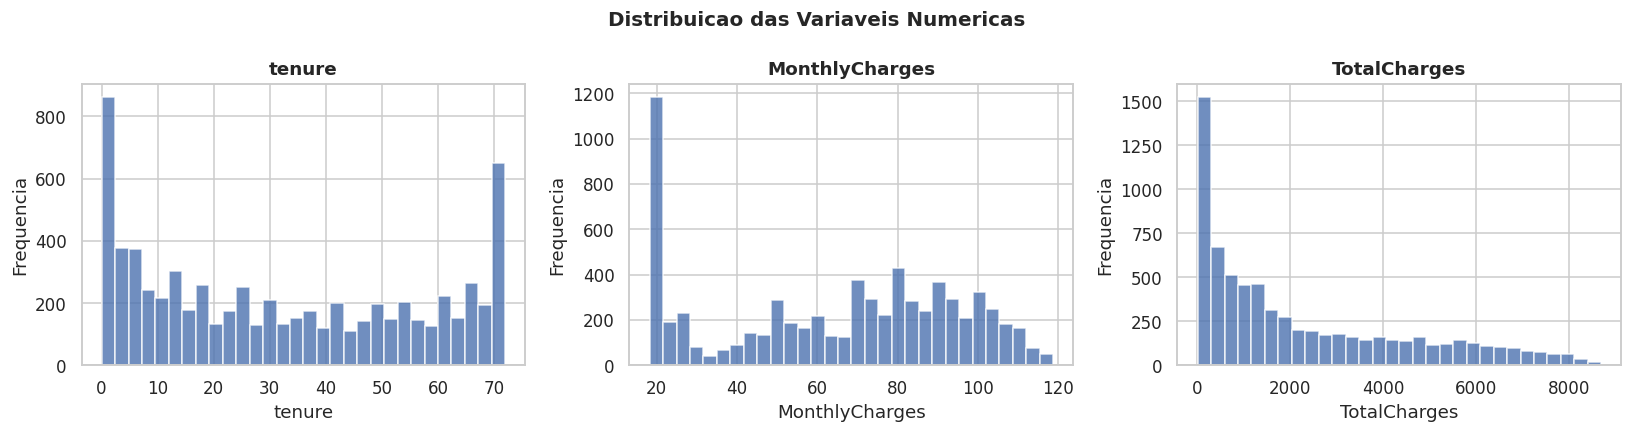

In [19]:
print('=== ANALISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===\n')
dist_rows = []
for col in NUM_COLS:
    skewness = df_base[col].skew()
    kurtosis = df_base[col].kurtosis()
    interp = ('Normal' if abs(skewness) < 0.5
              else ('Assimetrica a direita' if skewness > 0 else 'Assimetrica a esquerda'))
    dist_rows.append({'Coluna': col, 'Skewness': round(skewness, 3),
                      'Kurtosis': round(kurtosis, 3), 'Interpretacao': interp})

print(pd.DataFrame(dist_rows).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, NUM_COLS):
    ax.hist(df_base[col], bins=30, color='#4C72B0', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequencia')
plt.suptitle('Distribuicao das Variaveis Numericas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_PATH / 'eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Analise de Correlacoes

Objetivo: Identificar relacoes entre variaveis e detectar multicolinearidade

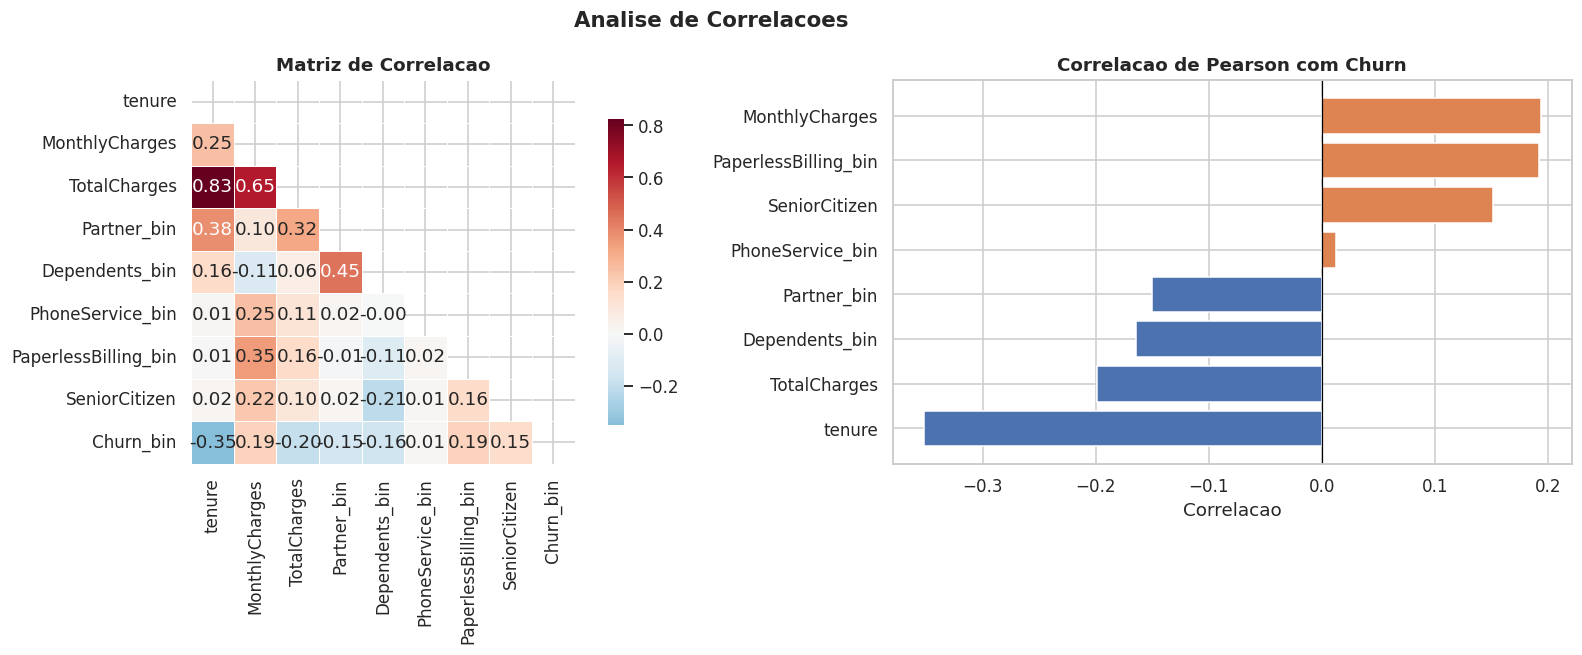

Top correlacoes com Churn:
tenure                 -0.352229
TotalCharges           -0.199037
MonthlyCharges          0.193356
PaperlessBilling_bin    0.191825
Dependents_bin         -0.164221
SeniorCitizen           0.150889
Partner_bin            -0.150448
PhoneService_bin        0.011942


In [20]:
df_corr = df_base.copy()
df_corr['Churn_bin'] = (df_corr['Churn'] == 'Yes').astype(int)

yes_no_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in yes_no_cols:
    df_corr[col + '_bin'] = (df_corr[col] == 'Yes').astype(int)

corr_cols = NUM_COLS + [c + '_bin' for c in yes_no_cols] + ['SeniorCitizen', 'Churn_bin']
corr_matrix = df_corr[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, square=True, linewidths=0.5, ax=axes[0],
    cbar_kws={'shrink': 0.8},
)
axes[0].set_title('Matriz de Correlacao', fontsize=12, fontweight='bold')

churn_corr = corr_matrix['Churn_bin'].drop('Churn_bin').sort_values()
colors = [PALETTE['Yes'] if v > 0 else PALETTE['No'] for v in churn_corr.values]
axes[1].barh(churn_corr.index, churn_corr.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlacao de Pearson com Churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Correlacao')

plt.suptitle('Analise de Correlacoes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_PATH / 'eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top correlacoes com Churn:')
print(churn_corr.sort_values(key=abs, ascending=False).to_string())

## Feature Engineering — Previa

Importando as funcoes do modulo `src/` para verificar as features criadas.

In [21]:
from src.data.preprocessing import clean_data
from src.features.engineering import add_features

df_proc = clean_data(df.copy())
df_eng = add_features(df_proc)
df_eng['Churn_label'] = df_eng['Churn'].map({0: 'No', 1: 'Yes'})

new_cols = [c for c in df_eng.columns if c not in df_proc.columns and c != 'Churn_label']
print(f'Novas features criadas ({len(new_cols)}): {new_cols}')
df_eng[new_cols + ['Churn']].head(5)

Novas features criadas (14): ['charges_per_tenure', 'is_new_customer', 'is_long_term', 'has_phoneservice', 'has_multiplelines', 'has_onlinesecurity', 'has_onlinebackup', 'has_deviceprotection', 'has_techsupport', 'has_streamingtv', 'has_streamingmovies', 'num_services', 'is_monthly_contract', 'is_electronic_check']


,charges_per_tenure,is_new_customer,is_long_term,has_phoneservice,has_multiplelines,has_onlinesecurity,has_onlinebackup,has_deviceprotection,has_techsupport,has_streamingtv,has_streamingmovies,num_services,is_monthly_contract,is_electronic_check,Churn
0,29.849970,1,0,0,0,0,1,0,0,0,0,1,1,1,0
1,1.675000,0,1,1,0,1,0,1,0,0,0,3,0,0,0
2,26.924987,1,0,1,0,1,1,0,0,0,0,3,1,0,1
3,0.940000,0,1,0,0,1,0,1,1,0,0,3,0,0,0
4,35.349982,1,0,1,0,0,0,0,0,0,0,1,1,1,1


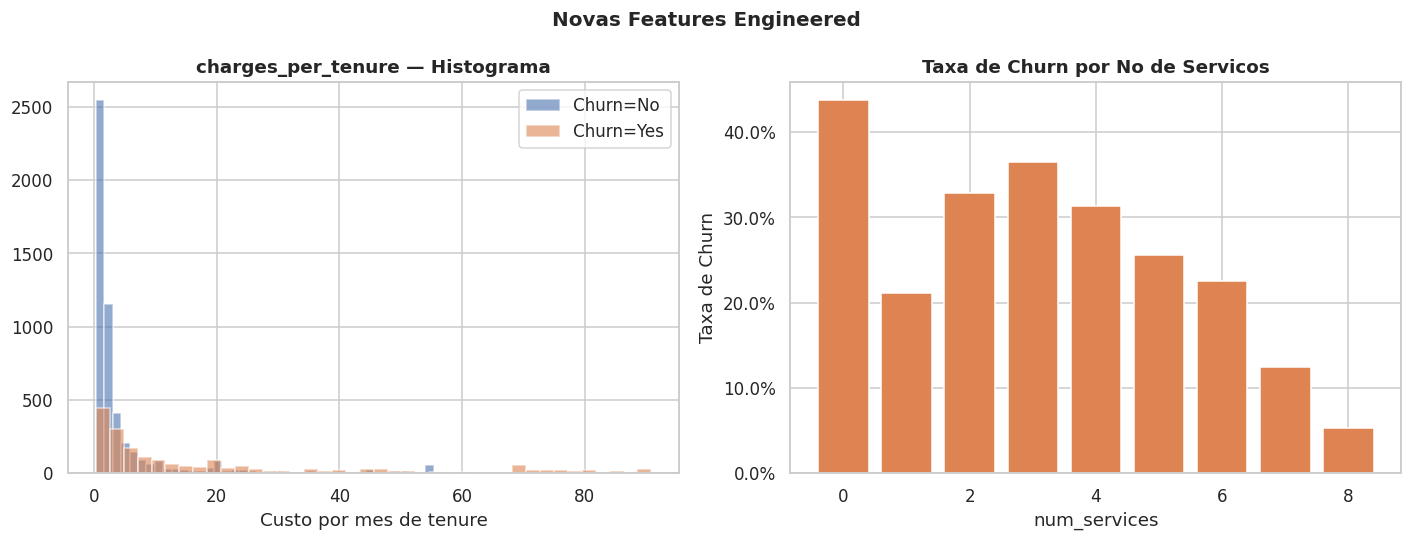

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for churn_val, color in PALETTE.items():
    subset = df_eng[df_eng['Churn_label'] == churn_val]['charges_per_tenure']
    axes[0].hist(subset.clip(upper=subset.quantile(0.99)),
                bins=40, alpha=0.6, color=color, label=f'Churn={churn_val}')
axes[0].set_title('charges_per_tenure — Histograma', fontweight='bold')
axes[0].set_xlabel('Custo por mes de tenure')
axes[0].legend()

num_svc_churn = df_eng.groupby('num_services')['Churn'].agg(['mean', 'count'])
axes[1].bar(num_svc_churn.index, num_svc_churn['mean'],
            color=PALETTE['Yes'], edgecolor='white')
axes[1].set_title('Taxa de Churn por No de Servicos', fontweight='bold')
axes[1].set_xlabel('num_services')
axes[1].set_ylabel('Taxa de Churn')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.suptitle('Novas Features Engineered', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_PATH / 'eda_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

Distribuicao das features engineered por segmento:

| Feature | Valor | N | Churn (%) |
| :--- | ---: | ---: | ---: |
| is_new_customer | 1 | ~1062 | ~56.2 |
| is_new_customer | 0 | ~5981 | ~21.3 |
| is_monthly_contract | 1 | ~3875 | ~42.7 |
| is_monthly_contract | 0 | ~3168 | ~6.8 |
| is_electronic_check | 1 | ~2365 | ~45.3 |
| is_electronic_check | 0 | ~4678 | ~17.1 |

## ML Canvas

| Campo | Detalhes |
| :--- | :--- |
| **Problema de negocio** | Operadora perde clientes em ritmo acelerado. Cada cancelamento representa perda de receita recorrente (LTV). |
| **Stakeholders** | Diretoria de Retencao, Customer Success, Time de Dados |
| **Metrica de negocio** | Custo de churn evitado = (clientes retidos) x (LTV medio) |
| **Metrica tecnica primaria** | **AUC-ROC** (ranking de risco) + **F1-Score** (threshold 0.5) |
| **Metrica secundaria** | **Recall** — minimizar falsos negativos (cliente que vai sair mas nao foi identificado) |
| **SLO** | AUC-ROC >= 0.80 em producao; latencia de inferencia <= 200ms |
| **Dataset** | IBM Telco Customer Churn — 7.043 clientes x 21 features |
| **Desbalanceamento** | ~73% No Churn / ~27% Churn — `class_weight='balanced'` ou SMOTE |
| **Modelo central** | MLP PyTorch (2-3 camadas ocultas, BatchNorm, Dropout, early stopping) |
| **Baselines** | DummyClassifier, Logistic Regression, Random Forest, Gradient Boosting |
| **Trade-off de custo** | Falso Negativo >> Falso Positivo (oferecer desconto a fiel e mais barato que perder um churner) |
| **Riscos** | Drift de distribuicao (novos planos, sazonalidade), vies demografico (genero, senioridade) |
| **Deploy** | FastAPI — inferencia real-time; batch scoring mensal para campanhas de retencao |
| **Monitoramento** | Drift de features, distribuicao de score, F1 em janela deslizante |

# Experimentacao e MVP (Minimum Viable Product)

## Regressao Logistica (Baseline)

### Separando dados de treino e teste com `train_test_split`

In [23]:
from src.data.preprocessing import build_full_pipeline
from sklearn.pipeline import Pipeline as SKPipeline

df_modelo = clean_data(df.copy())
X = df_modelo.drop(columns=['Churn'])
y = df_modelo['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')
print(f'Proporcao target treino:')
print(y_train.value_counts(normalize=True).round(3))

Treino: (5634, 19) | Teste: (1409, 19)
Proporcao target treino:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


### Separando dados com KFold e Validacao Cruzada

### Estratificando os dados

No processo de aleatorizacao do KFold simples, e dificil manter a proporcao dos dados, pois estao desbalanceados. Usamos **StratifiedKFold** para garantir a proporcao em cada fold.

In [24]:
def intervalo_conf(resultados, metrica='test_score'):
    media = resultados[metrica].mean()
    dp = resultados[metrica].std()
    print(f'  Media: {media:.4f} | DP: {dp:.4f} | '
          f'IC 95%: [{media - 2*dp:.4f}, {min(media + 2*dp, 1):.4f}]')

clf = LogisticRegression(random_state=SEED, max_iter=1000, class_weight='balanced')
pipeline_base = SKPipeline([
    ('transform', build_full_pipeline()),
    ('clf', clf),
])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print('=== VALIDACAO CRUZADA ESTRATIFICADA (5-fold) ===')
for scoring in ['recall', 'roc_auc', 'f1']:
    cv_res = cross_validate(pipeline_base, X_train, y_train, cv=skf, scoring=scoring)
    print(f'\n{scoring.upper()}:')
    intervalo_conf(cv_res)

=== VALIDACAO CRUZADA ESTRATIFICADA (5-fold) ===

RECALL:
  Media: 0.7960 | DP: 0.0336 | IC 95%: [0.7287, 0.8633]

ROC_AUC:
  Media: 0.8486 | DP: 0.0121 | IC 95%: [0.8245, 0.8728]

F1:
  Media: 0.6313 | DP: 0.0223 | IC 95%: [0.5868, 0.6759]


## Balanceamento de dados

Vamos comparar duas estrategias para lidar com o desbalanceamento:
- **class_weight='balanced'** — pesa inversamente a frequencia das classes
- **SMOTE** — cria amostras sinteticas da classe minoritaria (churn = 1)

In [25]:
pipeline_base.fit(X_train, y_train)
y_pred = pipeline_base.predict(X_test)
y_proba = pipeline_base.predict_proba(X_test)[:, 1]

print('=== RELATORIO DE CLASSIFICACAO (conjunto de teste) ===\n')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}')

=== RELATORIO DE CLASSIFICACAO (conjunto de teste) ===

              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

AUC-ROC: 0.8466


## Conclusoes e Data Readiness

In [26]:
churn_counts_final = df['Churn'].value_counts()
churn_pct_final = df['Churn'].value_counts(normalize=True) * 100

print('=' * 60)
print('RESUMO DE DATA READINESS')
print('=' * 60)
print(f'\nVolume         : {len(df):,} registros x {df.shape[1]} features')
print(f'Target         : Churn=Yes {churn_pct_final["Yes"]:.1f}% (desbalanceado)')
print(f'Missing values : TotalCharges — 11 registros (0.16%)')
print(f'Duplicatas     : 0')
print(f'Features raw   : {df.shape[1] - 2} (excluindo customerID e Churn)')
print(f'Features eng.  : +14 (apos feature engineering)')
print('\nTop predictors (correlacao com Churn):')
print('  1. Contract (Month-to-month vs anual)')
print('  2. tenure (negativo)')
print('  3. MonthlyCharges')
print('  4. InternetService (Fiber optic)')
print('  5. OnlineSecurity, TechSupport (ausencia)')
print('\nDecisoes de pre-processamento:')
print('  - TotalCharges: pd.to_numeric + imputacao pela mediana')
print('  - Target: binarizar Yes/No -> 1/0')
print('  - Numericas: StandardScaler')
print('  - Categoricas: OneHotEncoder(handle_unknown="ignore")')
print('  - Imbalance: class_weight="balanced" nos baselines sklearn')
print('  - Split: 80% treino / 20% teste (estratificado)')
print('\nStatus: Dataset PRONTO para modelagem')

RESUMO DE DATA READINESS

Volume         : 7,043 registros x 21 features
Target         : Churn=Yes 26.5% (desbalanceado)
Missing values : TotalCharges — 11 registros (0.16%)
Duplicatas     : 0
Features raw   : 19 (excluindo customerID e Churn)
Features eng.  : +14 (apos feature engineering)

Top predictors (correlacao com Churn):
  1. Contract (Month-to-month vs anual)
  2. tenure (negativo)
  3. MonthlyCharges
  4. InternetService (Fiber optic)
  5. OnlineSecurity, TechSupport (ausencia)

Decisoes de pre-processamento:
  - TotalCharges: pd.to_numeric + imputacao pela mediana
  - Target: binarizar Yes/No -> 1/0
  - Numericas: StandardScaler
  - Categoricas: OneHotEncoder(handle_unknown="ignore")
  - Imbalance: class_weight="balanced" nos baselines sklearn
  - Split: 80% treino / 20% teste (estratificado)

Status: Dataset PRONTO para modelagem


---
### Proximos Passos (Etapa 2)

1. Treinar baselines completos (DummyClassifier, Logistic Regression, Random Forest, Gradient Boosting) com **MLflow tracking**.
2. Construir **MLP PyTorch** com early stopping e batch normalization.
3. Comparar modelos usando AUC-ROC, F1, Precision, Recall, PR-AUC.
4. Analisar trade-off falso positivo vs. falso negativo (custo de negocio).
5. Registrar todos os experimentos no MLflow.